# End Use country clustering model

The workbook contains the entire pipeline for the clustering of fishing entities based on their socio-economical information

In [30]:
# STEP 1: Setting up of python environment for analysis
# Load libraries
import pandas as pd
from feature_engineering import transform_data
from dimension_reduction import dimension_reduction
from top_categories_per_type import plot_top_categories
from gdp_lat_cleaning import gdp_lat_cleaning
from hierarchical_clustering import plot_heatmap, plot_dendrogram
import numpy as np

# Set up file paths
raw_path = "../data/raw/adr6921_Suppl_Excel_v2.csv"
gdp_path = "../data/raw/compiled_gdp.csv"
mean_lat_path = "../data/raw/geo_mean_location.csv"
end_use_data_path = "../data/raw/sau_fishing_entity_info.csv"
country_path = "../data/raw/country_translations.csv"
output_path = '../data/processed/'
graph_output_path = '../results/'

In [31]:
# Read in raw data
df = pd.read_csv(raw_path, encoding_errors='replace')
gdp_per_capita = pd.read_csv(gdp_path)
mean_latitude = pd.read_csv(mean_lat_path)
end_use = pd.read_csv(end_use_data_path)
country_list = pd.read_csv(country_path)

# Transform data and obain final dataframe with counts of factories by country and attribute category
df = transform_data(df, False)

# Set 'country' as index
X = df.set_index('country')
# obtain features for clustering
X = X.drop(columns=['total_factories'])

## Dimension reduction for factory profile

In [32]:
n_components = 5

# Perform dimensionality reduction using NMF
W, H = dimension_reduction(X, n_components=n_components)

# Obtain list of countries in W
countries = W.index.tolist()

# Create with top categories contributing to each type
top_categories = plot_top_categories(H, 30, False)

In [33]:
clean_gdp = gdp_per_capita.set_index("country_name")[['GDP_per_capita']]
clean_latitude = mean_latitude.set_index("geo_name")[["lat"]]

In [34]:
# Obtain list of countries in SAU that need should be considered
countries = country_list[country_list['is_currently_used_for_reconstruction']
                         == True]['sau_name']
all_country = pd.DataFrame(index=countries)

# Obtain translation between fishing entity name in SAU to country names in mean latitude data
sau_lat_name = country_list[country_list['is_currently_used_for_reconstruction'] == True][[
    'sau_name', 'mean_lat_geo_name']]

# rename index of clean_latitude to match sau_lat_name
cleaned_latitude = clean_latitude.join(sau_lat_name.set_index(
    'mean_lat_geo_name'), how='inner').set_index('sau_name')

# add gdp and latitude to all countries
combined = all_country.join(clean_gdp, how='left').join(
    cleaned_latitude, how='left')

In [35]:
from sklearn.preprocessing import MinMaxScaler
# Scale GDP and latitude data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(combined)
combined[['GDP_per_capita', 'lat']] = scaled_data

In [36]:
# Keep only countries that are currrently used for reconstruction
sau_factory_name = country_list[country_list['is_currently_used_for_reconstruction'] == True][[
    'sau_name', 'factory_country']]


translated_W = W.join(sau_factory_name.set_index(
    'factory_country'), how='inner').set_index('sau_name')

In [37]:
combined = combined.join(translated_W, how='left').fillna(0)

In [38]:
# Transform and include factory count as a features in the final dataframe
# Obtain factory count dataframe to add to dataframe
factory_count = df[['country', 'total_factories']].set_index('country')

# log transform factory count to reduce skewness
logged_factory_count = np.log(factory_count)

# scale log transformed factory count
factory_scaler = MinMaxScaler()
scaled_factory_count = factory_scaler.fit_transform(logged_factory_count)
factory_count_logged_scaled = pd.DataFrame(
    scaled_factory_count, index=logged_factory_count.index,
    columns=['scaled_factory_count'])

# translate fishing entity names in factory counts to accepted names
translated_factory_count = factory_count_logged_scaled.join(
    sau_factory_name.set_index('factory_country'), how='inner').set_index('sau_name')

In [28]:
# combine factory count to the main dataframe
final = combined.join(translated_factory_count, how='left')

# fill in unknown values in factory count and end use profile
final['scaled_factory_count'] = final['scaled_factory_count'].fillna(0)

# NMF model for end use profiles

In [39]:
# change values of boolean columns
boolean_cols = ['dedicated_fleet?', 'DHC_byproduct?', 'poor_conditions',
                'tuna_ranching/direct_feeding/bait?', 'low_value_fish']
categorical_cols = ['wto_status', 'cashion_end_use_grouping', 'cashion_type']

end_use[boolean_cols] = end_use[boolean_cols].replace({'n': 0, 'y': 1})

In [40]:
end_use.head()

,fishing_entity_id,name,wto_status,cashion_end_use_grouping,dedicated_fleet?,DHC_byproduct?,poor_conditions,tuna_ranching/direct_feeding/bait?,low_value_fish,cashion_type
0,200,Alaska (USA),Others,Unknown,0,0,0,0,0,Unknown
1,1,Albania,Developed,only_bait,0,1,0,0,0,B
2,2,Algeria,Others,only_bait,0,0,0,1,0,C
3,3,American Samoa,Others,only_dhc,0,0,0,0,0,C
4,4,Angola,Least Developed,dedicated_industry,1,1,1,1,0,A


In [41]:
from sklearn.preprocessing import OneHotEncoder

# One hot encode categorical features to create a sparse matrix for non-negative factorization
encoder = OneHotEncoder(sparse_output=False)
ohe_df = encoder.fit_transform(end_use[categorical_cols])
one_hot_df = pd.DataFrame(ohe_df,
                          columns=encoder.get_feature_names_out(categorical_cols))
ohe_cashion = end_use.drop(
    columns=categorical_cols+['fishing_entity_id']).join(one_hot_df).set_index('name')

In [42]:
one_hot_df

,wto_status_Developed,wto_status_Developing,wto_status_Least Developed,wto_status_Others,cashion_end_use_grouping_Unknown,cashion_end_use_grouping_dedicated_industry,cashion_end_use_grouping_only_bait,cashion_end_use_grouping_only_dhc,cashion_type_A,cashion_type_B,cashion_type_C,cashion_type_Unknown
0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
212,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
213,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
214,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
215,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [21]:
ohe_cashion

,dedicated_fleet?,DHC_byproduct?,poor_conditions,tuna_ranching/direct_feeding/bait?,low_value_fish,wto_status_Developed,wto_status_Developing,wto_status_Least Developed,wto_status_Others,cashion_end_use_grouping_Unknown,cashion_end_use_grouping_dedicated_industry,cashion_end_use_grouping_only_bait,cashion_end_use_grouping_only_dhc,cashion_type_A,cashion_type_B,cashion_type_C,cashion_type_Unknown
name,,,,,,,,,,,,,,,,,
Alaska (USA),0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Albania,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Algeria,0,0,0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
American Samoa,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Angola,1,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Venezuela,0,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Viet Nam,0,0,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Wallis & Futuna Isl. (France),0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
end_use_np

array([[0, 0, 0, ..., nan, nan, nan],
       [0, 1, 0, ..., nan, nan, nan],
       [0, 0, 0, ..., nan, nan, nan],
       ...,
       [0, 0, 0, ..., nan, nan, nan],
       [0, 0, 0, ..., nan, nan, nan],
       [1, 0, 1, ..., nan, nan, nan]], shape=(217, 17), dtype=object)

### Find optimal number of NMF profiles

In [75]:
import nimfa

# Set the seed for numpy for reproducibility
np.random.seed(42)

# Set up end use info as matrix
end_use_np = ohe_cashion.to_numpy()
nmf = nimfa.Nmf(end_use_np, max_iter=200, seed='random')
np.mat = np.asmatrix

# Estimate rank for end use profile
rank_estimate = nmf.estimate_rank(rank_range=range(2, 15),
                                  n_run=30,
                                  what=['cophenetic', 'rss'])

# Extract the results
ranks = list(rank_estimate.keys())
coph_scores = [rank_estimate[r]['cophenetic'] for r in ranks]
rss_scores = [rank_estimate[r]['rss'] for r in ranks]

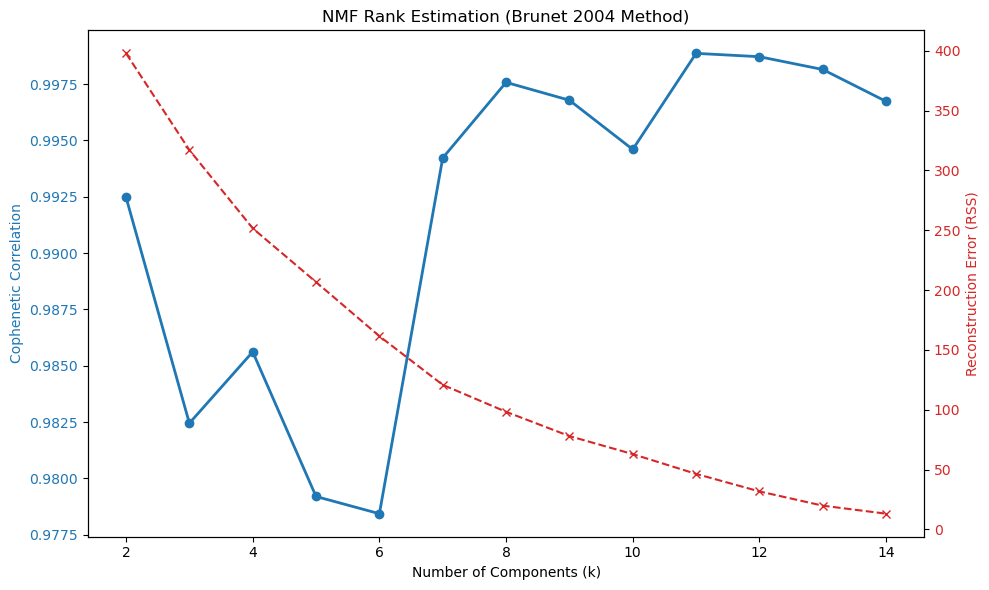

In [76]:
import matplotlib.pyplot as plt

# Plot the results to find the "drop-off"
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot Cophenetic Correlation (Look for the drop-off)
color = 'tab:blue'
ax1.set_xlabel('Number of Components (k)')
ax1.set_ylabel('Cophenetic Correlation', color=color)
ax1.plot(ranks, coph_scores, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# Plot Reconstruction Error (Look for the elbow)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Reconstruction Error (RSS)', color=color)
ax2.plot(ranks, rss_scores, marker='x', linestyle='--', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("NMF Rank Estimation (Brunet 2004 Method)")
fig.tight_layout()
plt.show()

From the graph we can see that the number of components best suited for NMF of end use profiles is 8 components. 

In [77]:
# Reduce dimensions using end use information and creating profiles
cashion_W, cashion_H = dimension_reduction(ohe_cashion, n_components=8)

# Show top categories contributing to each profile
plot_top_categories(cashion_H, 10, False)

alt.FacetChart(...)

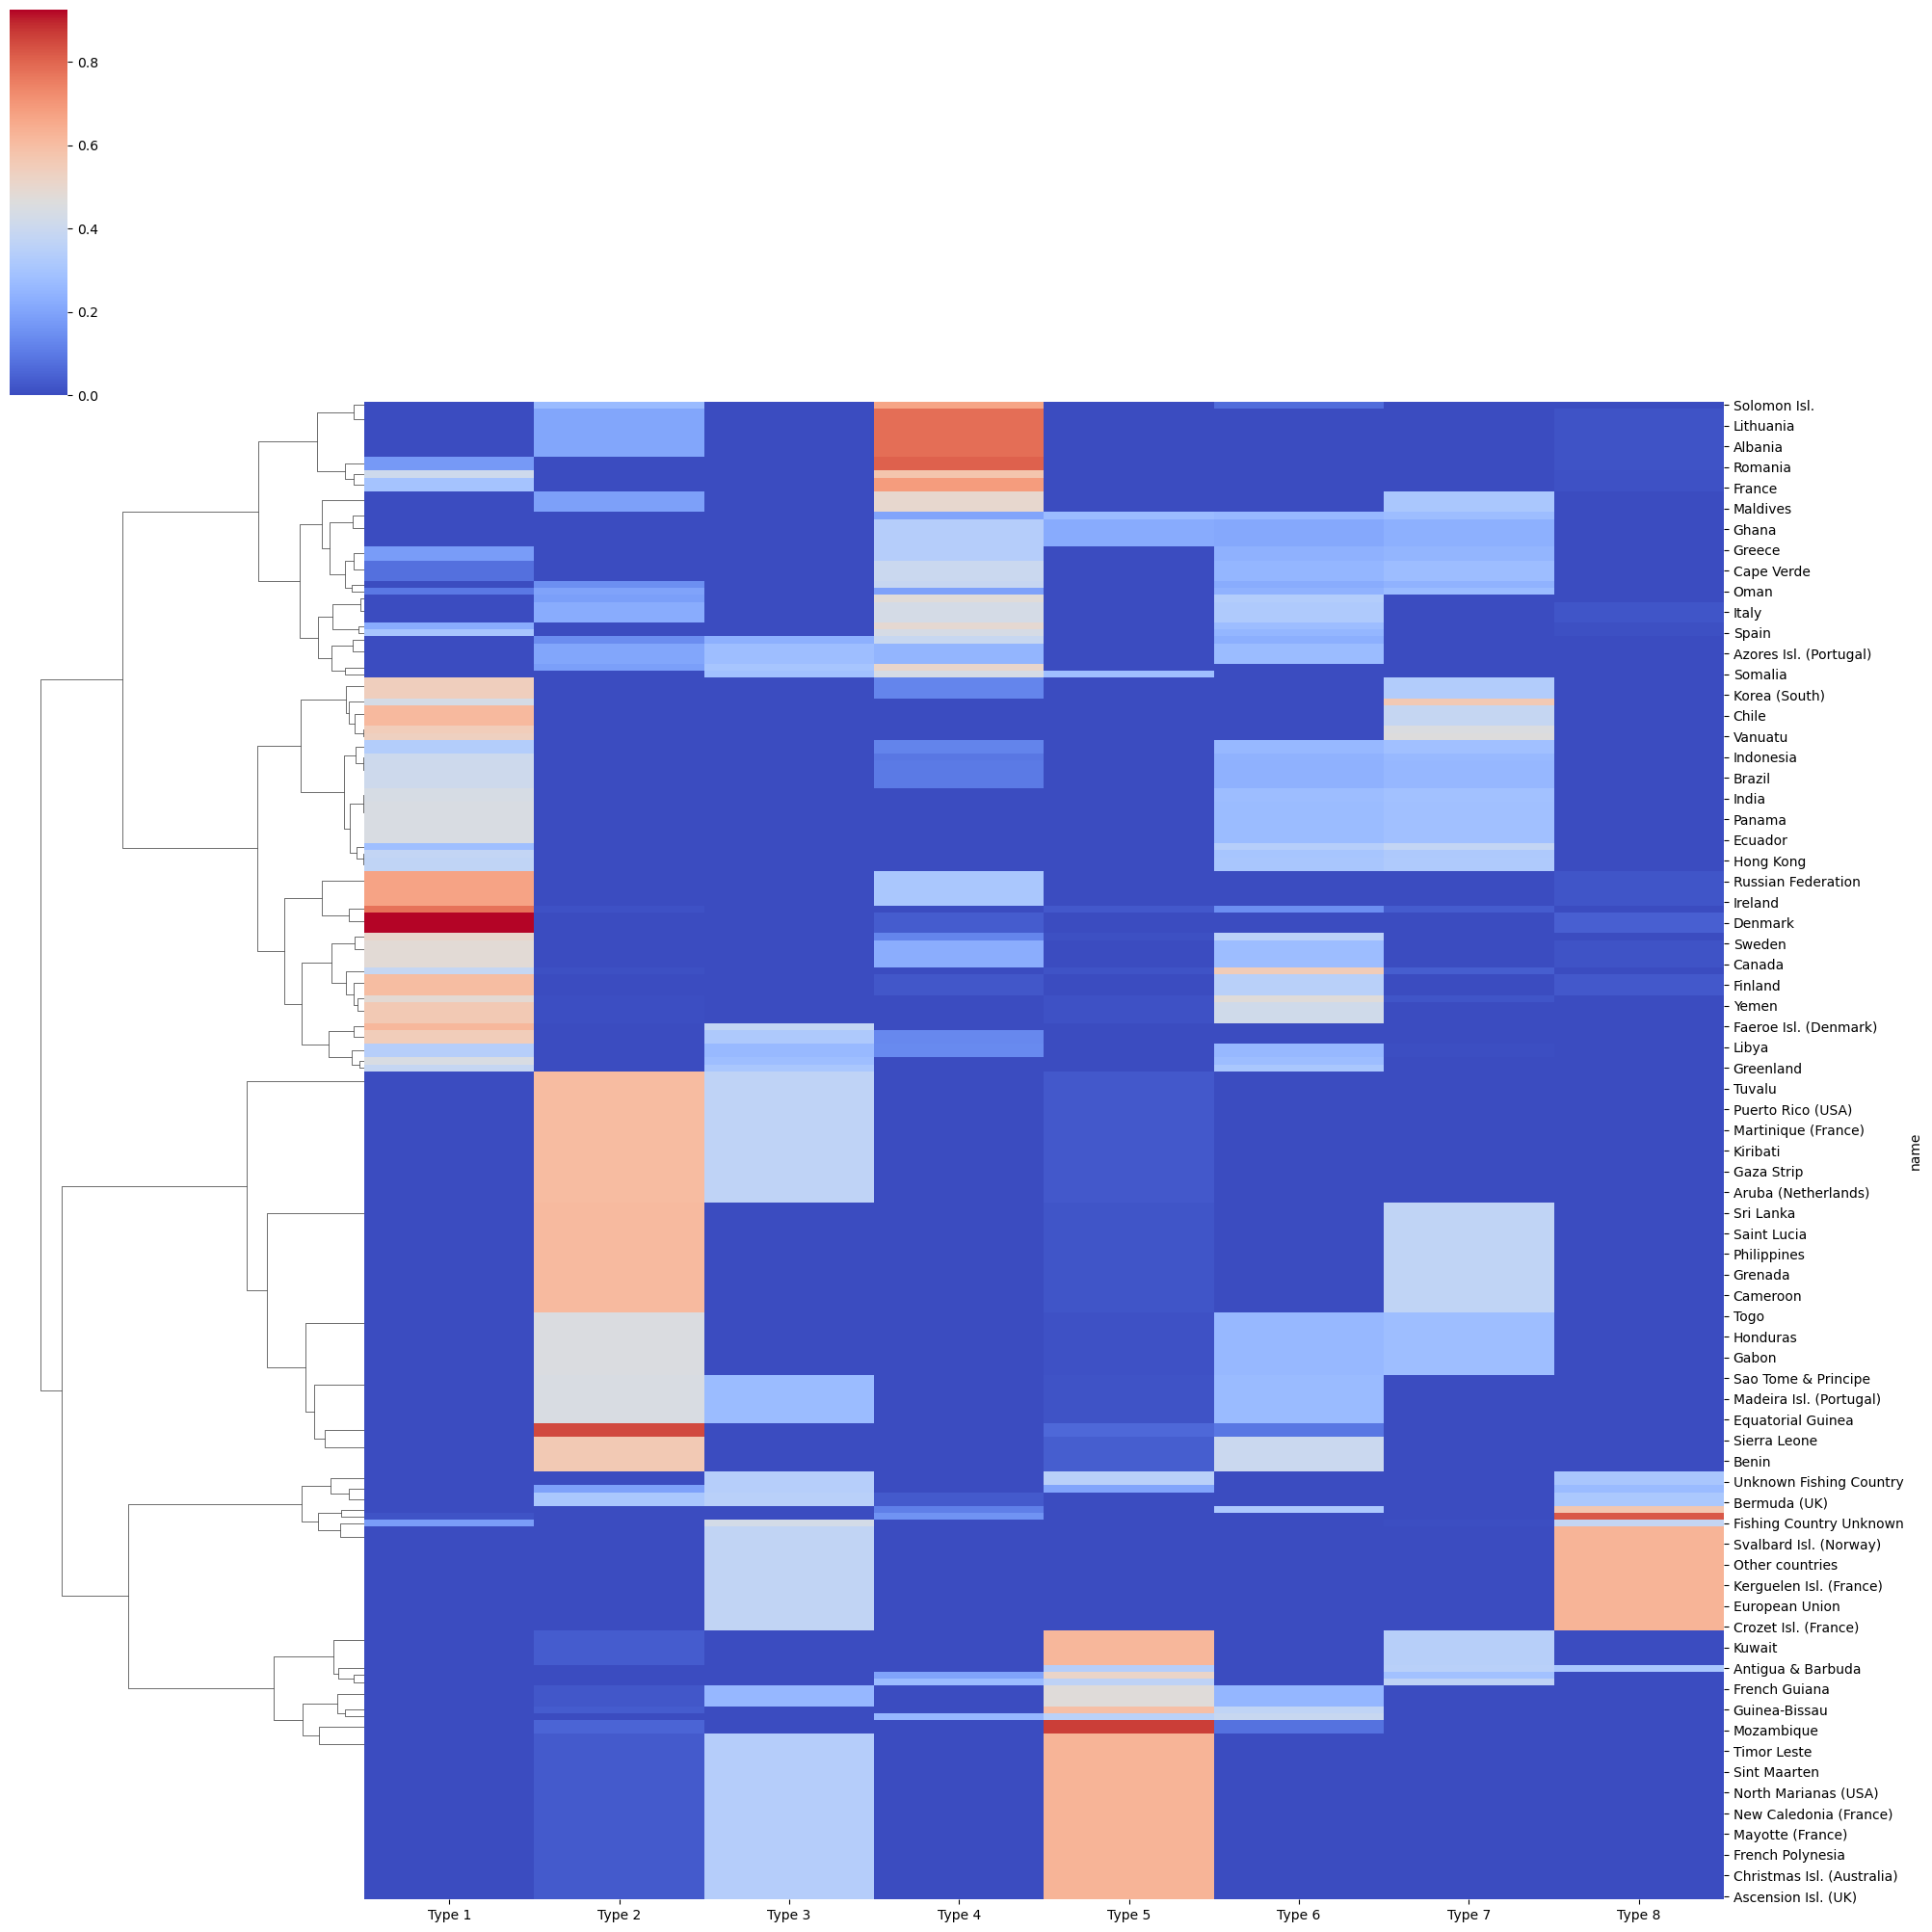

In [78]:
# Visualize heatmap for end use profiles
plot_heatmap(cashion_W, save_fig=False)

In [79]:
# Renaming profile features
cashion_W.rename(columns={'Type 1': 'cashion_type_1', 'Type 2': 'cashion_type_2', 'Type 3': 'cashion_type_3', 'Type 4': 'cashion_type_4',
                 'Type 5': 'cashion_type_5', 'Type 6': 'cashion_type_6', 'Type 7': 'cashion_type_7', 'Type 8': 'cashion_type_8'}, inplace=True)

In [80]:
# Combine end use profile, factory profiel, mean latitiude, and gdp per capita into one dataframe
combo = final[['GDP_per_capita', 'lat', 'Type 1', 'Type 2', 'Type 3',
               'Type 4', 'Type 5', 'scaled_factory_count']].join(cashion_W)

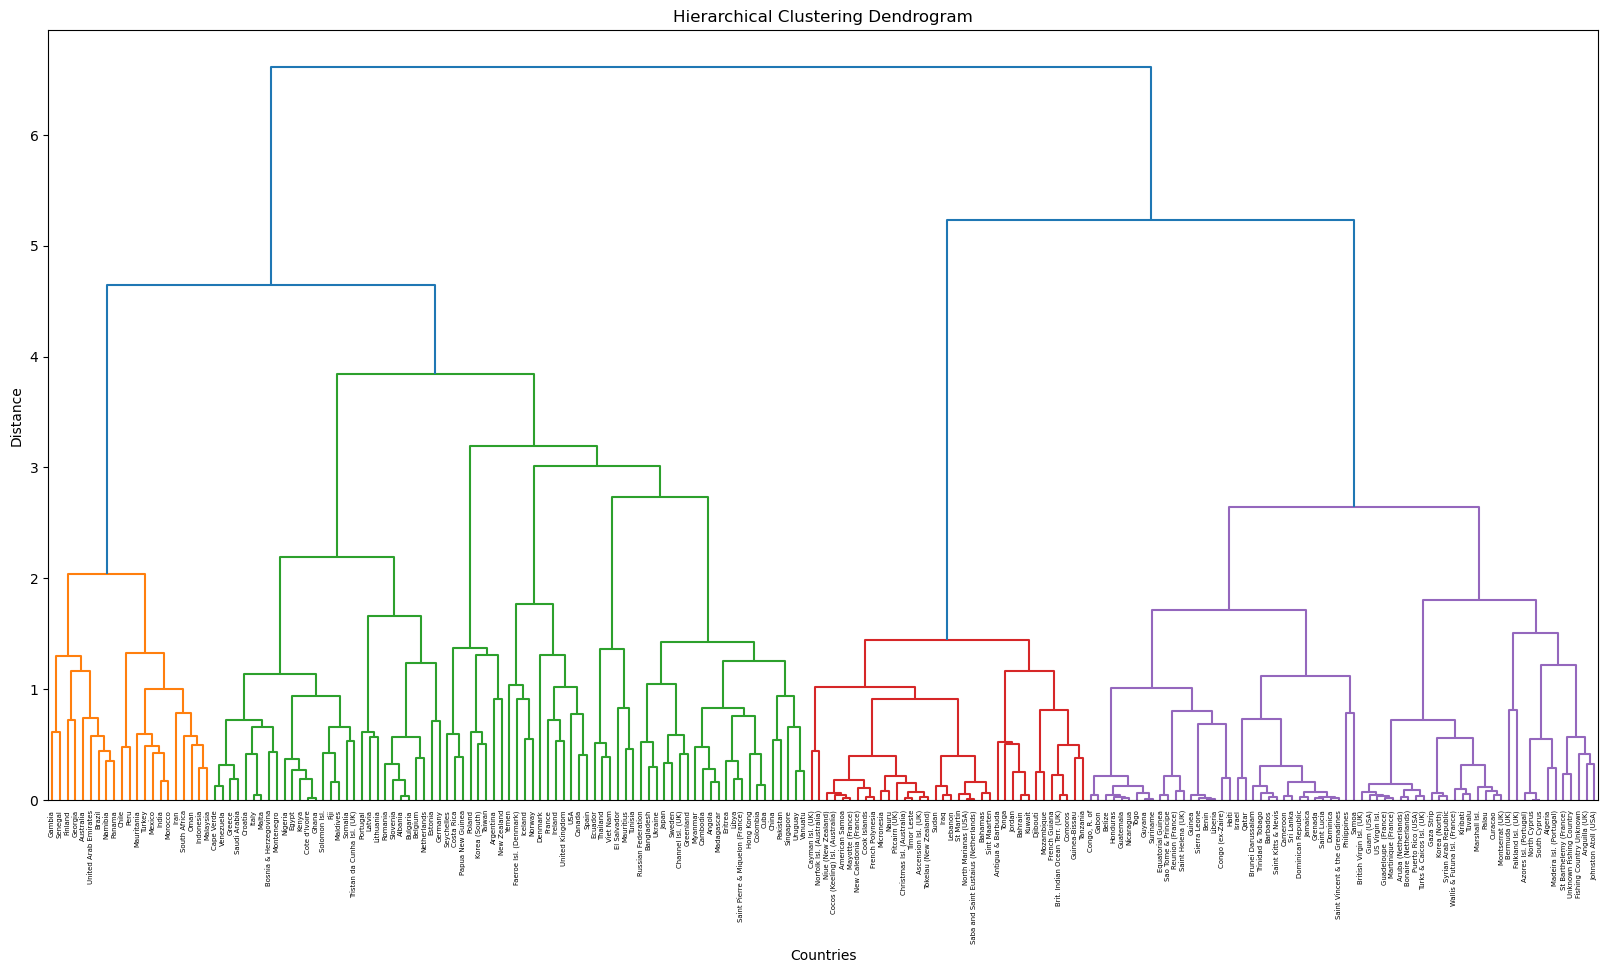

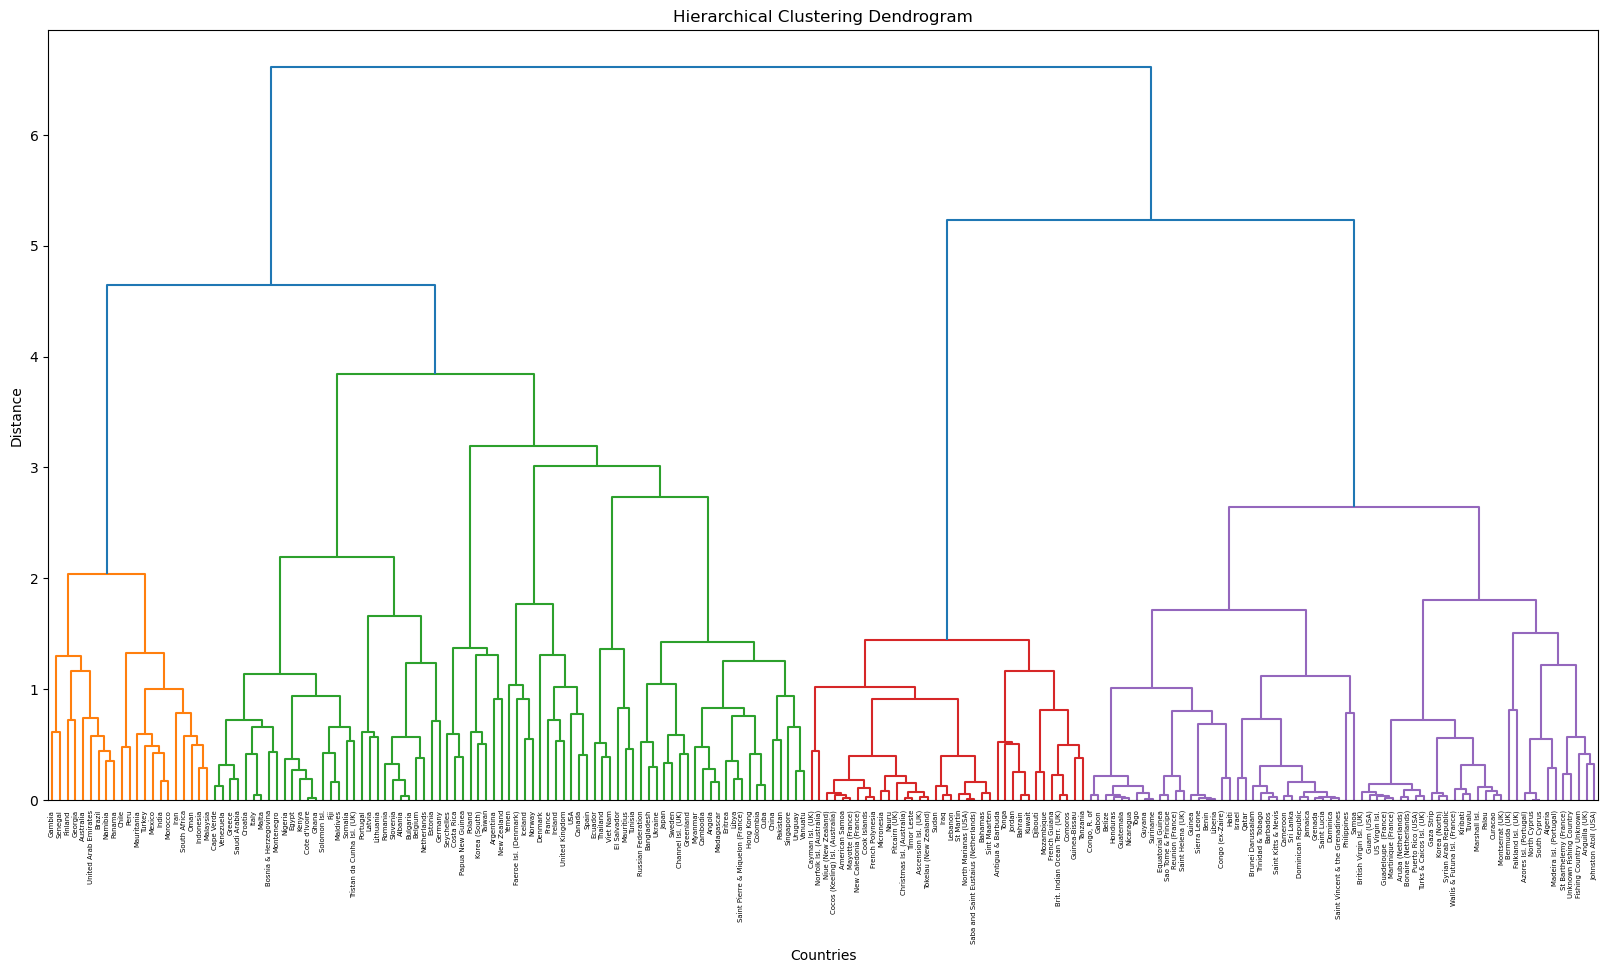

In [81]:
plot_dendrogram(combo, save_fig=False)

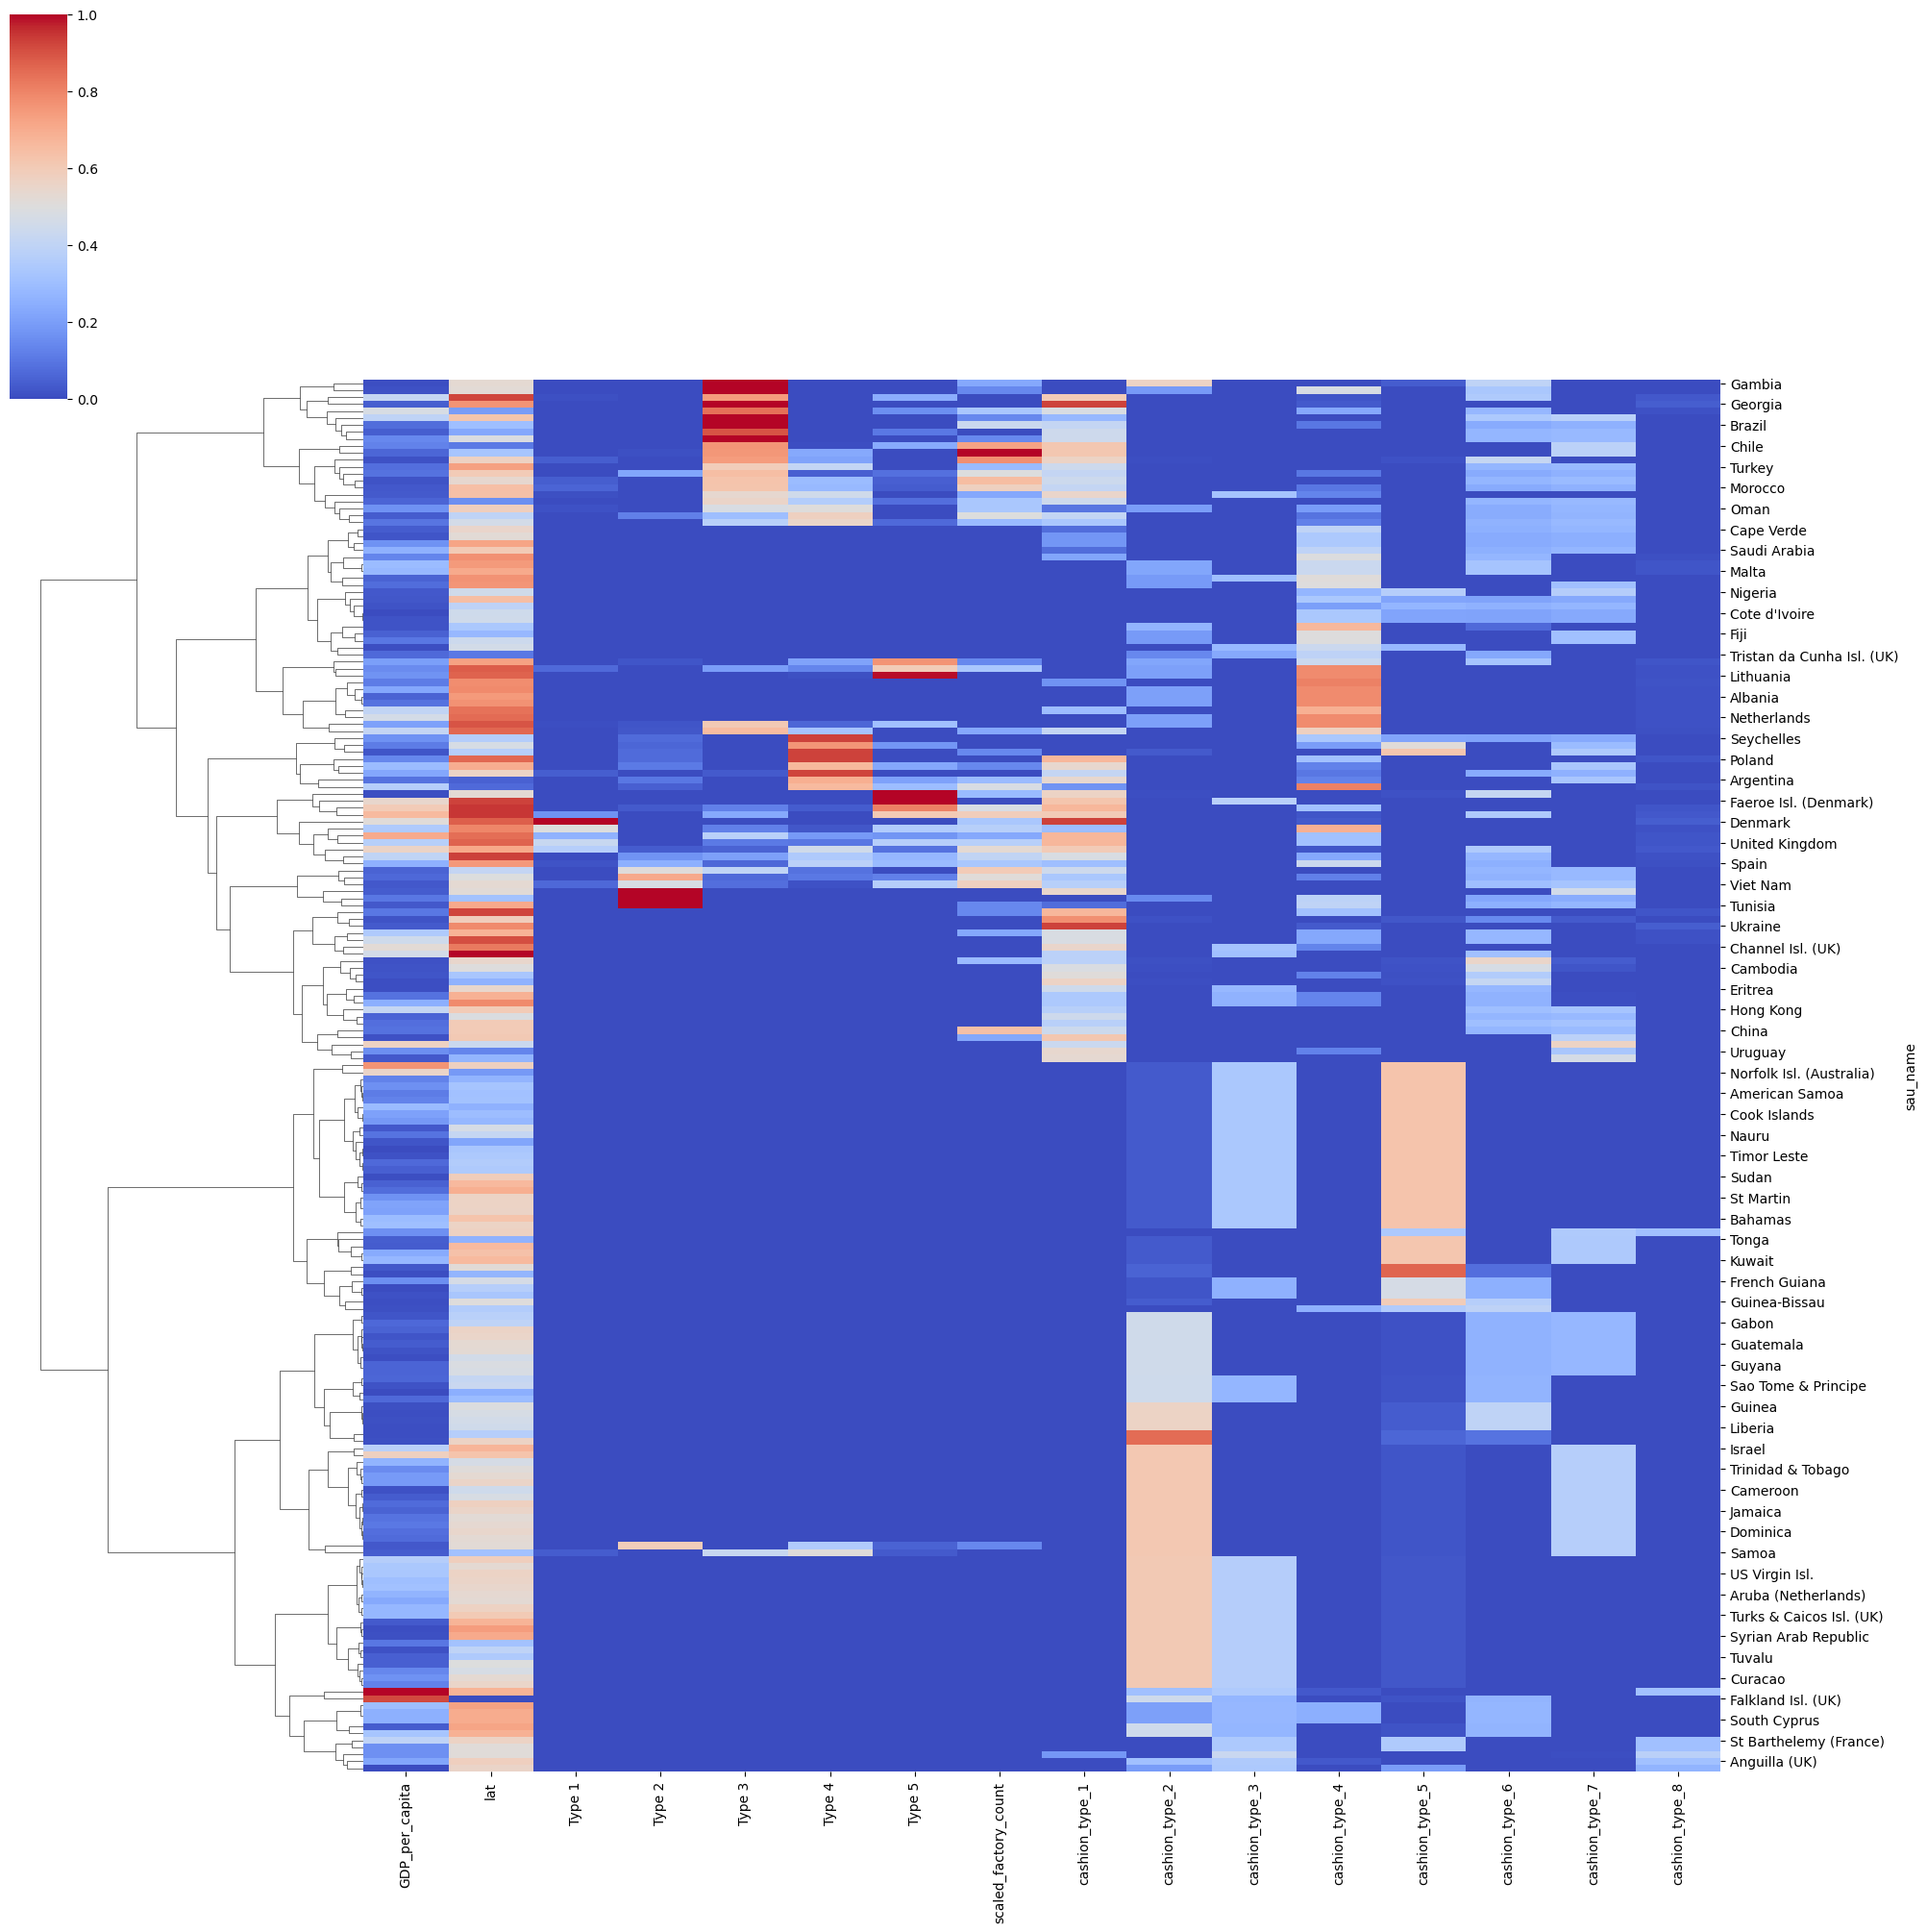

In [82]:
plot_heatmap(combo, save_fig=False)

In [83]:
# extracting resulting groupings based on max distance threshold
from scipy.cluster.hierarchy import linkage, fcluster

Z = linkage(combo, method='ward', metric='euclidean')

max_d = 1.5  # This is a distance threshold you can adjust

cluster_labels = fcluster(Z, t=max_d, criterion='distance')

results = pd.DataFrame({'Country': combo.index, 'Cluster': cluster_labels})

results.to_csv('../results/country_clusters.csv', index=False)